**MAIN GOAL**

To identify which ecosystem process (ET, WUE, NPP, Carbon) shows the earliest and most robust signs of loss of resilience under increased drought frequency in the Amazon.


| Bloco                                                             | Objetivo principal                                                                 | Perguntas que responde                                                                                         | Métodos / análises                                                                                                                                                                                                                                                                                                           | Principais outputs                                                                                                                                                                                                                                                                                                                                                                                           |
| ----------------------------------------------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **A – Early-warning signals (EWS)**                               | Detectar **perda de resiliência antes das quebras**                                | Existe perda de resiliência nas séries? Qual variável começa a perder resiliência primeiro?                    | - Detrending (GAM + STL/LOESS)<br> - Cálculo em janelas móveis de: **AR(1)**, **variância**, **coeficiente de variação (CV)**, **skewness**, **kurtosis**, **spectral reddening**<br> - Testes de tendência (Kendall τ, Sen slope) para cada EWS                                                                             | - Séries temporais de todos os EWS (por variável e cenário)<br> - Tabela com τ, p-value e **ano de início** do aumento de cada EWS<br> - **Ranking de variáveis** que dão sinal mais cedo (por cenário)                                                                                                                                                                                                      |
| **B – Breakpoints clássicos (sua análise original, fortalecida)** | Identificar **momentos de mudança estrutural** nas séries                          | Quando o sistema muda de regime em termos de média/tendência? As variáveis mudam no mesmo momento?             | - Métodos de **detecção de breakpoints em séries univariadas** (p.ex. `strucchange`, PELT, regressão segmentada simples)<br> - Aplicar o mesmo método a todas as variáveis e cenários<br> - Comparar posição dos breakpoints entre variáveis                                                                                 | - Ano(s) de breakpoint por variável e cenário<br> - Intervalos de confiança / incerteza desses anos (se disponível)<br> - Comparação direta: qual variável “quebra” primeiro em termos estruturais                                                                                                                                                                                                           |
| **C – Converging evidence em mudanças de tendência**              | Ver se os padrões de mudança são robustos a **múltiplos métodos**, incluindo o seu | As datas de mudança dependem do método? Tendência e sazonalidade contam a mesma história?                      | - **BFAST** (quebras em tendência + sazonalidade; se tiver dados mensais)<br> - **STL + trend filtering** na componente de tendência<br> - **Modelos state-space / Kalman** (local level / local linear trend) para tendências contínuas<br> - Comparar esses métodos com os **breakpoints clássicos do Bloco B**            | - Anos de breakpoints por BFAST<br> - Anos de mudanças de inclinação da tendência (trend filtering)<br> - Séries de tendência suavizada (state-space) e possíveis mudanças de regime<br> - Comparação entre métodos, mostrando se os breakpoints clássicos são robustos                                                                                                                                      |
| **D – Causalidade temporal (VAR / Granger / VAR-LASSO)**          | Entender **ordem temporal e influência entre processos**                           | ET/WUE antecipam NPP e Carbono? Quem dirige a dinâmica do sistema?                                             | - Construção de matrizes multivariadas (ET, WUE, NPP, Carbon) por cenário<br> - Modelos **VAR(p)** com seleção de ordem via AIC/BIC<br> - **Granger causality** para todos os pares X → Y<br> - **VAR-LASSO** para checar robustez da estrutura causal                                                                       | - Matriz de p-values de Granger (quem causa quem)<br> - Grafo causal (setas ET → NPP, etc.) por cenário<br> - Medidas de “out-degree” (quantas variáveis cada uma influencia)<br> - Comparação com ranking de EWS (A) e com o timing dos breakpoints (B–C)                                                                                                                                                   |
| **E – Critical transition timing & síntese avançada**             | Estimar **timing das transições com incerteza** e integrar todas as evidências     | Quando a transição ocorre (com IC)? Quando ela teria sido detectada “online”? O que tudo isso diz em conjunto? | - **Bayesian change point detection** (ex.: `bcp`, `mcp`) para cada série<br> - **Piecewise regression** com breakpoint(s) + incerteza (IC / bootstrap)<br> - **SPRT / CUSUM** para detecção “online” do primeiro desvio<br> - Integração com EWS (A), breakpoints clássicos (B), métodos de tendência (C) e causalidade (D) | - Breakpoints Bayesianos com **intervalos de credibilidade**<br> - Breakpoints frequentistas (piecewise) com IC<br> - Ano em que SPRT/CUSUM detecta mudança para cada variável (detecção “online”)<br> - **Linha do tempo integrada** por variável: início de EWS → detecção online → breakpoints (clássicos e bayesianos)<br> - Conclusão final sobre **quais processos são leading indicators** de colapso |


**A) EARLY WARNING SIGNALS**

*A.1 - Organizing data*


In [34]:
library(dplyr)
library(tidyr)
library(mgcv)
library(ggplot2)

In [35]:
annual_data <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/yearly_grouped.csv")

annual_long <- annual_data %>%
  rename(
    Year     = date,
    Scenario = frequency
  ) %>%
  select(Year, Scenario, npp, ctotal, evapm, wue) %>%
  # Drop years where all key variables are NA (post-collapse years)
  filter(!(is.na(npp) & is.na(ctotal) & is.na(evapm) & is.na(wue))) %>%
  pivot_longer(
    cols      = c(npp, ctotal, evapm, wue),
    names_to  = "Variable",
    values_to = "Value"
  )


In [36]:
print(unique(annual_long$Scenario))

[1] "1y"      "7y"      "regclim"


Detrending time series with GAM

In [37]:
#This code removes long-term temporal trends from annual model outputs using Generalized Additive Models (GAMs).
#For each combination of Scenario and Variable, a GAM is fitted with Year as a smooth predictor and the variable 
#value as the response. The smooth term captures the low-frequency (long-term) trend over time. 
#The residuals from this model represent the interannual variability after detrending and are stored as a new 
#column (residuals) in the dataset. The detrending is applied independently to each scenario–variable pair to 
#avoid mixing trends across different model configurations or output variables.

detrend_with_gam <- function(df) {
  # df must have Year and Value
  fit <- gam(Value ~ s(Year, k = 10), data = df)
  df$residuals <- residuals(fit)
  df
}

annual_detrended <- annual_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ detrend_with_gam(.x)) %>%
  ungroup()

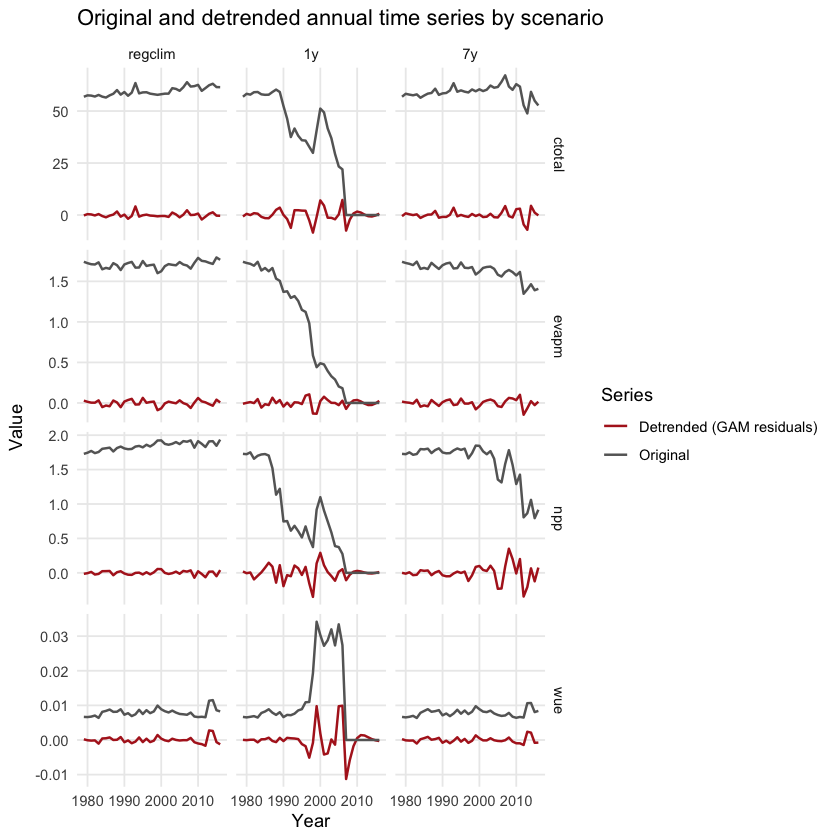

In [38]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Choose the scenarios you want to compare
scenarios_to_plot <- c("regclim", "1y", "7y")

annual_detrended %>%
  filter(Scenario %in% scenarios_to_plot) %>%
  # Put original and detrended values in long format for nicer plotting + legend
  pivot_longer(
    cols = c(Value, residuals),
    names_to = "Series",
    values_to = "TS_value"
  ) %>%
  mutate(
    # Nice labels for legend
    Series = recode(Series,
                    Value = "Original",
                    residuals = "Detrended (GAM residuals)"),
    # Optional: order scenarios in a meaningful way
    Scenario = factor(Scenario, levels = scenarios_to_plot)
  ) %>%
  ggplot(aes(x = Year, y = TS_value, color = Series)) +
  geom_line(linewidth = 0.7) +
  facet_grid(Variable ~ Scenario, scales = "free_y") +
  labs(
    x = "Year",
    y = "Value",
    title = "Original and detrended annual time series by scenario",
    color = "Series"
  ) +
  scale_color_manual(
    values = c("Original" = "grey40",
               "Detrended (GAM residuals)" = "firebrick")
  ) +
  theme_minimal() +
  theme(
    strip.background = element_blank(),
    panel.grid.minor = element_blank()
  )


Interpretation of detrended annual time series

The detrending procedure based on Generalized Additive Models (GAMs) successfully isolates the low-frequency temporal component of the annual time series. For all variables and scenarios, the residuals are centered around zero and preserve the interannual variability, indicating that the GAM smooth captures the long-term trend while removing systematic temporal structure from the residuals.

Clear differences emerge among the climate scenarios. The regclim and 7y scenarios exhibit relatively smooth long-term trajectories, with moderate interannual variability and comparable residual magnitudes across variables. In these scenarios, the detrended series can be interpreted as stationary interannual anomalies, suggesting that the system remains dynamically stable over most of the simulation period.

In contrast, the 1y scenario displays pronounced non-stationary behavior. All variables show abrupt declines and strong departures from their previous trajectories, consistent with a regime shift or systemic collapse in the modeled ecosystem. In this case, the GAM smooth is unable to fully capture the abrupt transition, resulting in substantially larger residual amplitudes. Consequently, the detrended series in the 1y scenario reflects not only interannual variability but also signals associated with structural instability of the system.

The comparison between scenarios suggests that increased climate forcing first manifests as enhanced variability (as observed in the 7y scenario) before leading to an abrupt loss of system stability under the most extreme forcing (1y). The marked increase in residual variance preceding and during the transition in the 1y scenario is consistent with theoretical expectations of resilience loss and may be interpreted as an early-warning signal of impending regime change.

*A.2 - Calculating EWS*


In [39]:
library(dplyr)
library(tidyr)
library(purrr)
library(mgcv)
library(earlywarnings)
library(Kendall)


First, we will use the residuals from the detrended TS from GAM. After, we will use the detrending from the R package earlywarnings. We will compare the differences

A.2.a. Using detrended from GAM	

In [40]:
library(e1071)  # for skewness and kurtosis
library(stats)

In [41]:

compute_ews_window <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance
    var_x <- var(xw, na.rm = TRUE)
    
    # Coefficient of variation
    mean_x <- mean(xw, na.rm = TRUE)
    cv_x <- ifelse(abs(mean_x) < .Machine$double.eps, NA, sqrt(var_x) / mean_x)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      CV          = cv_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [42]:

ews_gam_manual <- annual_detrended %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window(
        x    = .x$residuals,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [43]:
run_ews_gam <- function(df, winsize = 50) {
  # df must contain: Year, residuals
  
  # 1) Sort by time and remove NA residuals (e.g., post-collapse gaps)
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(residuals))
  
  # 2) If the cleaned series is too short, skip this group
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Build the time series matrix: first column = time, second = values
  ts_mat <- cbind(df_clean$Year, df_clean$residuals)
  
  # 4) Safely run generic_ews on GAM residuals
  ew <- tryCatch(
    suppressWarnings(
      generic_ews(
        timeseries    = ts_mat,
        winsize       = winsize,    # % of the available (pre-collapse) series
        detrending    = "no",       # GAM already removed the trend
        logtransform  = FALSE,
        interpolate   = FALSE,
        AR_n          = TRUE,
        powerspectrum = TRUE
      )
    ),
    error = function(e) NULL
  )
  
  if (is.null(ew)) return(NULL)
  
  as.data.frame(ew)
}


In [46]:
print(dim(ews_gam_manual))
print(head(ews_gam_manual))
print(names(ews_gam_manual))


[1] 240   9
# A tibble: 6 x 9
# Groups:   Scenario, Variable [1]
  Scenario Variable time_center   AR1 Variance      CV Skewness Kurtosis
  <chr>    <chr>          <dbl> <dbl>    <dbl>   <dbl>    <dbl>    <dbl>
1 1y       ctotal          1988 0.200     5.23   24.2    -0.989    1.78 
2 1y       ctotal          1989 0.258     9.08   -9.61   -1.39     2.13 
3 1y       ctotal          1990 0.288     9.05   -7.66   -1.31     1.99 
4 1y       ctotal          1991 0.199    12.0  -153.     -0.612    1.49 
5 1y       ctotal          1992 0.318    13.0    21.2    -0.592    1.02 
6 1y       ctotal          1993 0.291    13.1    53.0    -0.495    0.879
# i 1 more variable: Reddening <dbl>
[1] "Scenario"    "Variable"    "time_center" "AR1"         "Variance"   
[6] "CV"          "Skewness"    "Kurtosis"    "Reddening"  


In [47]:
library(Kendall)
library(tidyr)

ews_long_gam <- ews_gam_manual %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam <- ews_long_gam %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_gam)


# A tibble: 72 x 5
   Scenario Variable Indicator    tau           p
   <chr>    <chr>    <chr>      <dbl>       <dbl>
 1 1y       ctotal   AR1       -0.463 0.00476    
 2 1y       ctotal   CV        -0.147 0.381      
 3 1y       ctotal   Kurtosis  -0.274 0.0980     
 4 1y       ctotal   Reddening -0.505 0.00205    
 5 1y       ctotal   Skewness   0.737 0.00000644 
 6 1y       ctotal   Variance   0.484 0.00315    
 7 1y       evapm    AR1        0.663 0.0000501  
 8 1y       evapm    CV         0.126 0.456      
 9 1y       evapm    Kurtosis   0.358 0.0297     
10 1y       evapm    Reddening  0.874 0.000000119
# i 62 more rows


Adding missing grouping variables: `Scenario`, `Variable`


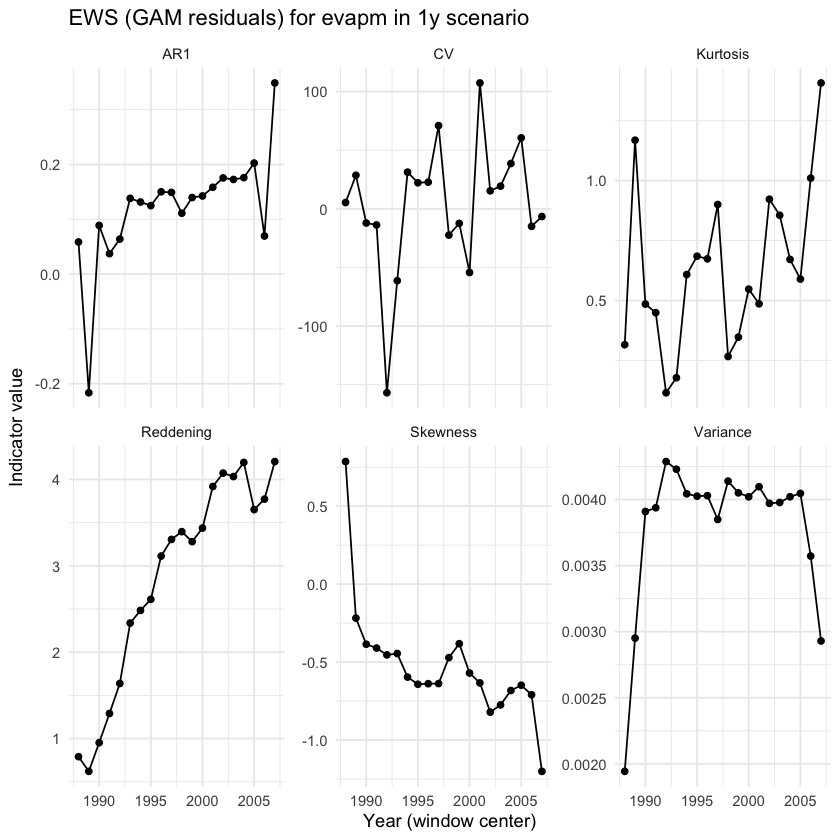

In [48]:
# Filter one Scenario × Variable
ews_one <- ews_gam_manual %>%
  filter(Scenario == "1y", Variable == "evapm") %>%
  select(time_center, AR1, Variance, CV, Skewness, Kurtosis, Reddening)

# Convert to long format for plotting
ews_one_long <- ews_one %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Line plot with facets for each indicator
ggplot(ews_one_long, aes(x = time_center, y = Value)) +
  geom_line() +
  geom_point() +
  facet_wrap(~ Indicator, scales = "free_y") +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Indicator value",
    title = "EWS (GAM residuals) for evapm in 1y scenario"
  )

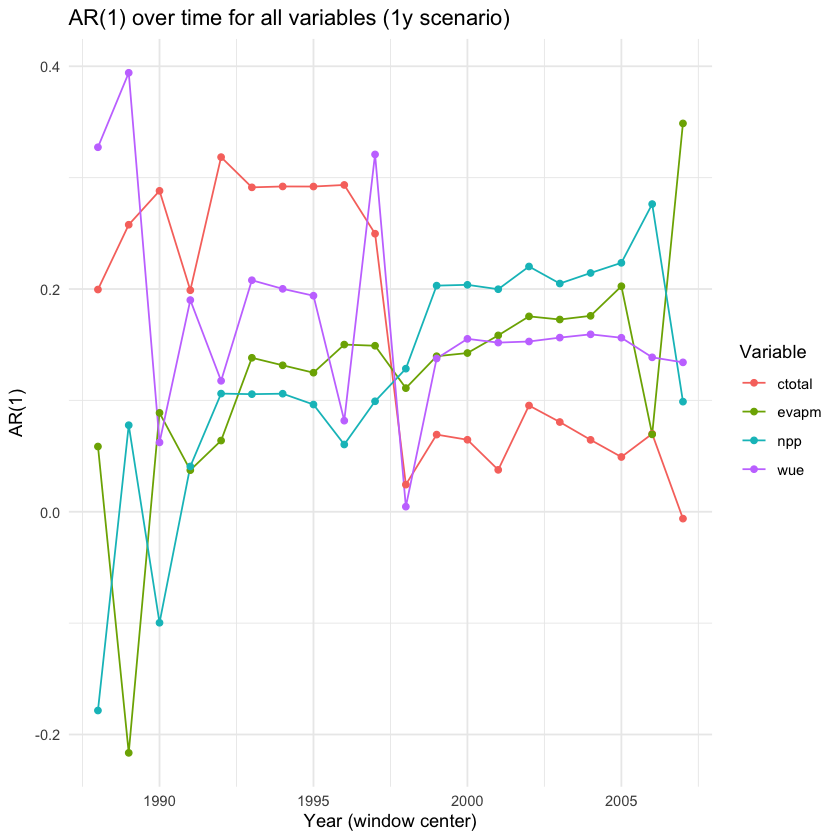

In [49]:
# Filter one scenario and keep only AR1
ews_ar1 <- ews_gam_manual %>%
  filter(Scenario == "1y") %>%
  select(Scenario, Variable, time_center, AR1)

ggplot(ews_ar1, aes(x = time_center, y = AR1, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "AR(1)",
    title = "AR(1) over time for all variables (1y scenario)"
  )


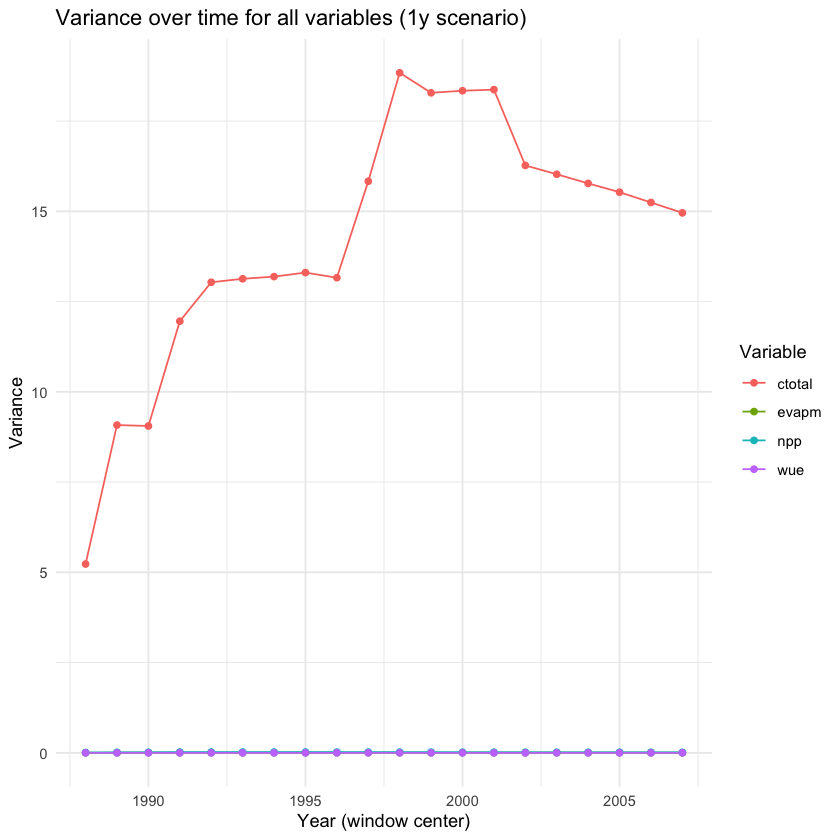

In [50]:
ews_var <- ews_gam_manual %>%
  filter(Scenario == "1y") %>%
  select(Scenario, Variable, time_center, Variance)

ggplot(ews_var, aes(x = time_center, y = Variance, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Variance",
    title = "Variance over time for all variables (1y scenario)"
  )


In [51]:
ews_long_gam <- ews_gam_manual %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam <- ews_long_gam %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )


In [52]:
# annual_detrended must already exist and contain:
# Year, Scenario, Variable, Value, residuals

annual_detrended_std <- annual_detrended %>%
  group_by(Scenario, Variable) %>%
  mutate(
    # Standardised residuals: mean = 0, sd = 1 within each Scenario × Variable
    residuals_std = as.numeric(scale(residuals))
  ) %>%
  ungroup()


In [53]:
compute_ews_window_std <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (standardised residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance (on standardised residuals)
    var_x <- var(xw, na.rm = TRUE)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [54]:
library(purrr)

ews_gam_std <- annual_detrended_std %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window_std(
        x    = .x$residuals_std,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [56]:
library(tidyr)
library(Kendall)

ews_long_std <- ews_gam_std %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_std <- ews_long_std %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_std)


# A tibble: 60 x 5
   Scenario Variable Indicator     tau           p
   <chr>    <chr>    <chr>       <dbl>       <dbl>
 1 1y       ctotal   AR1       -0.463  0.00476    
 2 1y       ctotal   Kurtosis  -0.274  0.0980     
 3 1y       ctotal   Reddening -0.505  0.00205    
 4 1y       ctotal   Skewness   0.737  0.00000644 
 5 1y       ctotal   Variance   0.484  0.00315    
 6 1y       evapm    AR1        0.663  0.0000501  
 7 1y       evapm    Kurtosis   0.358  0.0297     
 8 1y       evapm    Reddening  0.874  0.000000119
 9 1y       evapm    Skewness  -0.663  0.0000500  
10 1y       evapm    Variance  -0.0105 0.974      
# i 50 more rows


In [58]:
find_onset <- function(time, value, k = 3, frac_baseline = 0.3) {
  n <- length(value)
  if (n == 0 || all(is.na(value))) return(NA_real_)
  
  baseline_n <- max(5, floor(frac_baseline * n))
  base_vals  <- value[1:baseline_n]
  thr <- median(base_vals, na.rm = TRUE) + sd(base_vals, na.rm = TRUE)
  
  above <- value > thr
  
  run_len <- 0
  onset_time <- NA_real_
  
  for (i in seq_along(above)) {
    if (isTRUE(above[i])) {
      run_len <- run_len + 1
      if (run_len >= k) {
        onset_time <- time[i]
        break
      }
    } else {
      run_len <- 0
    }
  }
  
  onset_time
}

core_indicators <- c("AR1", "Variance")

onset_std <- ews_long_std %>%
  filter(Indicator %in% core_indicators) %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    onset_time = find_onset(time_center, Value),
    .groups    = "drop"
  )

variable_level_onset_std <- onset_std %>%
  group_by(Scenario, Variable) %>%
  summarise(
    earliest_onset = min(onset_time, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(Scenario, earliest_onset)

print(variable_level_onset_std)


Warning message:
"There was 1 warning in `summarise()`.
i In argument: `earliest_onset = min(onset_time, na.rm = TRUE)`.
i In group 2: `Scenario = "1y"` and `Variable = "evapm"`.
Caused by warning in `min()`:
! nenhum argumento n~ao faltante para min; retornando Inf"


# A tibble: 12 x 3
   Scenario Variable earliest_onset
   <chr>    <chr>             <dbl>
 1 1y       wue                1998
 2 1y       ctotal             1999
 3 1y       npp                2001
 4 1y       evapm               Inf
 5 7y       evapm              1995
 6 7y       npp                1995
 7 7y       ctotal             1998
 8 7y       wue                2005
 9 regclim  ctotal             1995
10 regclim  evapm              1998
11 regclim  npp                2002
12 regclim  wue                2003


In [60]:
print(variable_level_onset_std %>% filter(Scenario == "1y"))


# A tibble: 4 x 3
  Scenario Variable earliest_onset
  <chr>    <chr>             <dbl>
1 1y       wue                1998
2 1y       ctotal             1999
3 1y       npp                2001
4 1y       evapm               Inf


In [61]:
library(dplyr)
library(tidyr)
library(Kendall)

# EWS table using standardised residuals (from previous steps)
# ews_gam_std has: Scenario, Variable, time_center, AR1, Variance, Skewness, Kurtosis, Reddening

ews_evap_1y <- ews_gam_std %>%
  filter(Scenario == "1y", Variable == "evapm")

# Look at Kendall trends for each indicator
Kendall(ews_evap_1y$time_center, ews_evap_1y$AR1)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Variance)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Reddening)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Skewness)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Kurtosis)


tau = 0.663, 2-sided pvalue =5.0068e-05

tau = -0.0105, 2-sided pvalue =0.97412

tau = 0.874, 2-sided pvalue =1.1921e-07

tau = -0.663, 2-sided pvalue =5.002e-05

tau = 0.358, 2-sided pvalue =0.029723

In [62]:
find_onset_soft <- function(time, value,
                            frac_baseline = 0.4,
                            n_sigma       = 0.5,
                            k             = 2) {
  n <- length(value)
  if (n == 0 || all(is.na(value))) return(NA_real_)
  
  baseline_n <- max(5, floor(frac_baseline * n))
  
  base_vals <- value[1:baseline_n]
  thr <- median(base_vals, na.rm = TRUE) + n_sigma * sd(base_vals, na.rm = TRUE)
  
  above <- value > thr
  
  run_len <- 0
  onset_time <- NA_real_
  
  for (i in seq_along(above)) {
    if (isTRUE(above[i])) {
      run_len <- run_len + 1
      if (run_len >= k) {
        onset_time <- time[i]
        break
      }
    } else {
      run_len <- 0
    }
  }
  
  onset_time
}


In [64]:
# Long format for evapm–1y
ews_evap_1y_long <- ews_evap_1y %>%
  select(time_center, AR1, Variance, Reddening, Skewness, Kurtosis) %>%
  pivot_longer(
    cols = c(AR1, Variance, Reddening, Skewness, Kurtosis),
    names_to = "Indicator",
    values_to = "Value"
  )

# Onset per indicator using the softer rule
onset_evap_soft <- ews_evap_1y_long %>%
  group_by(Indicator) %>%
  summarise(
    onset_time = find_onset_soft(time_center, Value),
    .groups    = "drop"
  )

print(onset_evap_soft)



Adding missing grouping variables: `Scenario`, `Variable`


# A tibble: 5 x 2
  Indicator onset_time
  <chr>          <dbl>
1 AR1             1997
2 Kurtosis        1996
3 Reddening       1994
4 Skewness          NA
5 Variance          NA


In [66]:
earliest_evap_onset <- onset_evap_soft %>%
  filter(Indicator %in% c("AR1", "Variance", "Reddening")) %>%
  summarise(min_onset = min(onset_time, na.rm = TRUE))

print(earliest_evap_onset)

# A tibble: 1 x 1
  min_onset
      <dbl>
1      1994


In [68]:
# Long EWS table using standardised residuals
ews_long_std2 <- ews_gam_std %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Soft onset per Scenario × Variable × Indicator
onset_soft_all <- ews_long_std2 %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    onset_time = find_onset_soft(time_center, Value),
    .groups    = "drop"
  )

# Earliest onset per variable using core indicators
core_indicators <- c("AR1", "Variance", "Reddening")

variable_level_onset_soft <- onset_soft_all %>%
  filter(Indicator %in% core_indicators) %>%
  group_by(Scenario, Variable) %>%
  summarise(
    earliest_onset = {
      x <- onset_time
      if (all(is.na(x))) NA_real_ else min(x, na.rm = TRUE)
    },
    .groups = "drop"
  ) %>%
  arrange(Scenario, earliest_onset)

variable_level_onset_soft


# A tibble: 12 x 3
   Scenario Variable earliest_onset
   <chr>    <chr>             <dbl>
 1 1y       wue                1989
 2 1y       npp                1993
 3 1y       ctotal             1994
 4 1y       evapm              1994
 5 7y       ctotal             1989
 6 7y       evapm              1989
 7 7y       wue                1991
 8 7y       npp                1993
 9 regclim  evapm              1989
10 regclim  wue                1991
11 regclim  ctotal             1992
12 regclim  npp                1997


A.2.b. Using detrended from internal ews package

In [86]:
library(dplyr)
library(tidyr)

# annual_detrended already exists and contains: Year, Scenario, Variable, Value, residuals
annual_long <- annual_detrended %>%
  select(Year, Scenario, Variable, Value) %>%
  distinct()

print(annual_long %>%
  count(Scenario, Variable))


# A tibble: 12 x 3
   Scenario Variable     n
   <chr>    <chr>    <int>
 1 1y       ctotal      38
 2 1y       evapm       38
 3 1y       npp         38
 4 1y       wue         38
 5 7y       ctotal      38
 6 7y       evapm       38
 7 7y       npp         38
 8 7y       wue         38
 9 regclim  ctotal      38
10 regclim  evapm       38
11 regclim  npp         38
12 regclim  wue         38


In [87]:
library(earlywarnings)

run_ews_default_vec <- function(df, winsize = 50, detrending = "gaussian") {
  # df must contain: Year, Value
  
  # 1) Sort by time and remove missing values
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(Value))
  
  # 2) Skip if the cleaned series is too short
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Use only the value vector; time index will be implicit (1,2,3,...)
  ts_vec <- df_clean$Value
  
  ew <- tryCatch(
    generic_ews(
      timeseries    = ts_vec,      # numeric vector
      winsize       = winsize,     # percentage of series length
      detrending    = detrending,  # "gaussian" is standard
      logtransform  = FALSE,
      interpolate   = FALSE,
      AR_n          = FALSE,
      powerspectrum = FALSE
    ),
    error = function(e) {
      message("generic_ews error: ", conditionMessage(e))
      NULL
    }
  )
  
  if (is.null(ew)) return(NULL)
  
  ew_df <- as.data.frame(ew)
  
  # In vector mode, generic_ews usually returns a column 'tim' with window index
  if ("tim" %in% names(ew_df)) {
    ew_df <- ew_df %>% rename(time = tim)
  }
  
  ew_df
}


In [ ]:
library(purrr)

ews_default <- annual_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ {
    ew <- run_ews_default_vec(.x, winsize = 50, detrending = "gaussian")
    
    if (is.null(ew)) {
      tibble()
    } else {
      as_tibble(ew)
    }
  }) %>%
  ungroup()


In [91]:
library(earlywarnings)

# Example: evapm in 1y scenario
x_evap_1y <- annual_long %>%
  filter(Scenario == "1y", Variable == "evapm") %>%
  arrange(Year)

